## Data Preprocessing

In [1]:
import os
import sys
import warnings

import numpy as np
import pandas as pd

if not sys.warnoptions:
    warnings.simplefilter("ignore")
    os.environ["PYTHONWARNINGS"] = "ignore"

##################################
# Loading in data
##################################
restaurants = pd.read_csv("healthinspections_2024_withsvi.csv")
restaurants

,Unnamed: 0,INSPECTION_DATE,STORE_NAME,STREET_ADDRESS,CITY,ZIP5,SERVICE_DESCRIPTION,SCORE,GRADE,STREET_ADDRESS_LINE2,...,MP_ASIAN,EP_AIAN,MP_AIAN,EP_NHPI,MP_NHPI,EP_TWOMORE,MP_TWOMORE,EP_OTHERRACE,MP_OTHERRACE,ZCTA5
0,0,2024-01-02,3RD ST CHEVRON,3817 W 3RD ST,LOS ANGELES,90020,ROUTINE INSPECTION,90.0,A,NaN,...,2.0,0.1,0.1,0.1,0.1,3.4,0.8,0.5,0.3,90004.0
1,1,2024-01-02,7-ELEVEN #34473B,5905 SOUTH ST,LAKEWOOD,90713,ROUTINE INSPECTION,97.0,A,NaN,...,2.1,0.1,0.1,0.8,0.6,5.5,1.5,0.6,0.3,90713.0
2,2,2024-01-02,7-ELEVEN #39023B,4111 VENICE BLVD,LOS ANGELES,90019,ROUTINE INSPECTION,96.0,A,NaN,...,1.5,0.1,0.1,0.1,0.1,3.2,1.0,0.8,0.5,90019.0
3,3,2024-01-02,7-ELEVEN #39714,6051 HOLLYWOOD BLVD # 111,LOS ANGELES,90028,ROUTINE INSPECTION,94.0,A,NaN,...,2.5,0.9,0.5,0.0,0.1,4.5,1.0,1.8,0.8,90028.0
4,4,2024-01-02,AEIRLOOM-CATCHER,10550 RIVERSIDE DR,NORTH HOLLYWOOD,91602,ROUTINE INSPECTION,92.0,A,NaN,...,2.6,0.4,0.4,0.2,0.2,4.7,1.4,0.6,0.5,91602.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
52938,52938,2024-01-02,Subway #43833,7709 E BEN WHITE BLVD EB SVRD,AUSTIN,78744.0,Routine Inspection,91.0,NaN,Unit 104,...,0.9,0.2,0.1,0.1,0.1,2.7,0.7,0.0,0.1,78741.0
52939,52939,2024-01-02,ZZa Pizza + Salad,15511 W SH 71,BEE CAVE,78738.0,Routine Inspection,92.0,NaN,UNIT 150,...,3.1,0.1,0.1,0.0,0.2,2.3,1.0,0.1,0.1,78738.0
52940,52940,2024-01-02,International Food Market,11331 N LAMAR BLVD,AUSTIN,78753.0,Routine Inspection,89.0,NaN,Unit H,...,1.9,0.0,0.1,0.0,0.1,2.6,1.3,0.3,0.3,78753.0
52941,52941,2024-01-02,Jack in the Box #912,6540 ED BLUESTEIN SB BLVD,AUSTIN,78723.0,Routine Inspection,94.0,NaN,NaN,...,1.4,0.0,0.1,0.0,0.1,3.6,1.4,0.3,0.2,78723.0


In [2]:
# encoding datetime information before training model
restaurants["INSPECTION_DATE"] = restaurants["INSPECTION_DATE"].astype("datetime64[ns]")
restaurants["INSPDATE_MONTH"] = restaurants["INSPECTION_DATE"].dt.month
restaurants["INSPDATE_DAY"] = restaurants["INSPECTION_DATE"].dt.day
restaurants

,Unnamed: 0,INSPECTION_DATE,STORE_NAME,STREET_ADDRESS,CITY,ZIP5,SERVICE_DESCRIPTION,SCORE,GRADE,STREET_ADDRESS_LINE2,...,MP_AIAN,EP_NHPI,MP_NHPI,EP_TWOMORE,MP_TWOMORE,EP_OTHERRACE,MP_OTHERRACE,ZCTA5,INSPDATE_MONTH,INSPDATE_DAY
0,0,2024-01-02,3RD ST CHEVRON,3817 W 3RD ST,LOS ANGELES,90020,ROUTINE INSPECTION,90.0,A,NaN,...,0.1,0.1,0.1,3.4,0.8,0.5,0.3,90004.0,1,2
1,1,2024-01-02,7-ELEVEN #34473B,5905 SOUTH ST,LAKEWOOD,90713,ROUTINE INSPECTION,97.0,A,NaN,...,0.1,0.8,0.6,5.5,1.5,0.6,0.3,90713.0,1,2
2,2,2024-01-02,7-ELEVEN #39023B,4111 VENICE BLVD,LOS ANGELES,90019,ROUTINE INSPECTION,96.0,A,NaN,...,0.1,0.1,0.1,3.2,1.0,0.8,0.5,90019.0,1,2
3,3,2024-01-02,7-ELEVEN #39714,6051 HOLLYWOOD BLVD # 111,LOS ANGELES,90028,ROUTINE INSPECTION,94.0,A,NaN,...,0.5,0.0,0.1,4.5,1.0,1.8,0.8,90028.0,1,2
4,4,2024-01-02,AEIRLOOM-CATCHER,10550 RIVERSIDE DR,NORTH HOLLYWOOD,91602,ROUTINE INSPECTION,92.0,A,NaN,...,0.4,0.2,0.2,4.7,1.4,0.6,0.5,91602.0,1,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
52938,52938,2024-01-02,Subway #43833,7709 E BEN WHITE BLVD EB SVRD,AUSTIN,78744.0,Routine Inspection,91.0,NaN,Unit 104,...,0.1,0.1,0.1,2.7,0.7,0.0,0.1,78741.0,1,2
52939,52939,2024-01-02,ZZa Pizza + Salad,15511 W SH 71,BEE CAVE,78738.0,Routine Inspection,92.0,NaN,UNIT 150,...,0.1,0.0,0.2,2.3,1.0,0.1,0.1,78738.0,1,2
52940,52940,2024-01-02,International Food Market,11331 N LAMAR BLVD,AUSTIN,78753.0,Routine Inspection,89.0,NaN,Unit H,...,0.1,0.0,0.1,2.6,1.3,0.3,0.3,78753.0,1,2
52941,52941,2024-01-02,Jack in the Box #912,6540 ED BLUESTEIN SB BLVD,AUSTIN,78723.0,Routine Inspection,94.0,NaN,NaN,...,0.1,0.0,0.1,3.6,1.4,0.3,0.2,78723.0,1,2


In [3]:
# subsetting to only CA
restaurants = restaurants[restaurants["STATE"] == "CA"]
restaurants

,Unnamed: 0,INSPECTION_DATE,STORE_NAME,STREET_ADDRESS,CITY,ZIP5,SERVICE_DESCRIPTION,SCORE,GRADE,STREET_ADDRESS_LINE2,...,MP_AIAN,EP_NHPI,MP_NHPI,EP_TWOMORE,MP_TWOMORE,EP_OTHERRACE,MP_OTHERRACE,ZCTA5,INSPDATE_MONTH,INSPDATE_DAY
0,0,2024-01-02,3RD ST CHEVRON,3817 W 3RD ST,LOS ANGELES,90020,ROUTINE INSPECTION,90.0,A,NaN,...,0.1,0.1,0.1,3.4,0.8,0.5,0.3,90004.0,1,2
1,1,2024-01-02,7-ELEVEN #34473B,5905 SOUTH ST,LAKEWOOD,90713,ROUTINE INSPECTION,97.0,A,NaN,...,0.1,0.8,0.6,5.5,1.5,0.6,0.3,90713.0,1,2
2,2,2024-01-02,7-ELEVEN #39023B,4111 VENICE BLVD,LOS ANGELES,90019,ROUTINE INSPECTION,96.0,A,NaN,...,0.1,0.1,0.1,3.2,1.0,0.8,0.5,90019.0,1,2
3,3,2024-01-02,7-ELEVEN #39714,6051 HOLLYWOOD BLVD # 111,LOS ANGELES,90028,ROUTINE INSPECTION,94.0,A,NaN,...,0.5,0.0,0.1,4.5,1.0,1.8,0.8,90028.0,1,2
4,4,2024-01-02,AEIRLOOM-CATCHER,10550 RIVERSIDE DR,NORTH HOLLYWOOD,91602,ROUTINE INSPECTION,92.0,A,NaN,...,0.4,0.2,0.2,4.7,1.4,0.6,0.5,91602.0,1,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37638,37638,2024-12-31,STANDARD STATIONS SPORTS BAR,226 STANDARD ST,EL SEGUNDO,90245.0,ROUTINE INSPECTION,73.0,C,NaN,...,0.1,0.0,0.2,8.8,2.5,0.1,0.1,90245.0,12,31
37639,37639,2024-12-31,SUBWAY,657 W REDONDO BEACH BLVD,GARDENA,90247.0,ROUTINE INSPECTION,95.0,A,NaN,...,0.1,0.0,0.1,2.8,0.9,0.7,0.4,90247.0,12,31
37640,37640,2024-12-31,SUBWAY #3675,5841 FIRESTONE BLVD,SOUTH GATE,90280.0,ROUTINE INSPECTION,91.0,A,STE #D,...,0.1,0.2,0.2,0.2,0.1,0.2,0.2,90280.0,12,31
37641,37641,2024-12-31,SUBWAY #44267,700 W IMPERIAL HWY # 107,LOS ANGELES,90044.0,ROUTINE INSPECTION,95.0,A,NaN,...,0.2,0.1,0.1,0.8,0.3,0.4,0.2,90044.0,12,31


In [4]:
# will ignore inspection_type for now, since our main
# predictors are the social vulnerability scores
# restaurants["SERVICE_DESCRIPTION"].unique()

## Subsetting for two training datasets (scores and grades)

Ask team about whether we want to include the adjunct race variables on the last page.

In [5]:
# creating training dataset from subset of restaurants dataset (using scores)
CA_restaurant_model_scores = restaurants[
    [
        "INSPDATE_YEAR",
        "INSPDATE_MONTH",
        "INSPDATE_DAY",
        "EP_POV150",
        "EP_UNEMP",
        "EP_HBURD",
        "EP_NOHSDP",
        "EP_UNINSUR",
        "EP_AGE65",
        "EP_AGE17",
        "EP_DISABL",
        "EP_SNGPNT",
        "EP_LIMENG",
        "EP_MINRTY",
        "EP_MUNIT",
        "EP_MOBILE",
        "EP_CROWD",
        "EP_NOVEH",
        "EP_GROUPQ",
        "SCORE",
    ]
]
CA_restaurant_model_scores

,INSPDATE_YEAR,INSPDATE_MONTH,INSPDATE_DAY,EP_POV150,EP_UNEMP,EP_HBURD,EP_NOHSDP,EP_UNINSUR,EP_AGE65,EP_AGE17,EP_DISABL,EP_SNGPNT,EP_LIMENG,EP_MINRTY,EP_MUNIT,EP_MOBILE,EP_CROWD,EP_NOVEH,EP_GROUPQ,SCORE
0,2024,1,2,31.9,7.4,48.8,22.9,15.5,12.0,18.4,8.5,6.0,21.3,79.4,51.8,0.2,18.5,16.9,1.6,90.0
1,2024,1,2,7.9,5.6,16.5,8.0,3.0,14.2,19.7,9.4,3.2,2.9,54.5,1.6,0.0,3.5,1.7,0.2,97.0
2,2024,1,2,28.0,8.5,41.3,21.6,15.0,14.3,17.1,9.4,5.6,17.2,82.5,25.5,0.2,12.3,13.2,2.4,96.0
3,2024,1,2,31.3,10.3,46.8,10.1,12.6,13.3,7.3,13.9,2.2,12.9,57.7,82.9,0.0,8.1,27.4,6.0,94.0
4,2024,1,2,13.3,7.8,34.3,4.8,5.6,13.0,12.2,7.8,3.2,2.9,40.6,55.2,0.4,3.6,4.7,0.0,92.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37638,2024,12,31,6.9,5.4,17.6,1.7,1.9,12.4,20.8,7.8,5.3,0.8,42.5,18.5,0.0,1.8,2.2,0.2,73.0
37639,2024,12,31,21.4,4.9,36.7,22.4,11.0,14.6,20.1,11.4,8.0,16.6,93.5,24.6,5.6,14.6,6.3,1.4,95.0
37640,2024,12,31,25.3,7.8,38.9,41.1,13.7,11.3,24.8,8.8,8.7,22.7,97.4,9.3,1.5,21.9,8.1,0.1,91.0
37641,2024,12,31,40.2,10.3,51.5,36.2,13.7,9.6,29.6,12.8,13.5,18.9,98.8,15.8,0.4,18.2,16.6,0.7,95.0


In [6]:
# creating training dataset from subset of restaurants dataset (using grades)
CA_restaurant_model_grades = restaurants[
    [
        "INSPDATE_YEAR",
        "INSPDATE_MONTH",
        "INSPDATE_DAY",
        "EP_POV150",
        "EP_UNEMP",
        "EP_HBURD",
        "EP_NOHSDP",
        "EP_UNINSUR",
        "EP_AGE65",
        "EP_AGE17",
        "EP_DISABL",
        "EP_SNGPNT",
        "EP_LIMENG",
        "EP_MINRTY",
        "EP_MUNIT",
        "EP_MOBILE",
        "EP_CROWD",
        "EP_NOVEH",
        "EP_GROUPQ",
        "GRADE",
    ]
]
CA_restaurant_model_grades

,INSPDATE_YEAR,INSPDATE_MONTH,INSPDATE_DAY,EP_POV150,EP_UNEMP,EP_HBURD,EP_NOHSDP,EP_UNINSUR,EP_AGE65,EP_AGE17,EP_DISABL,EP_SNGPNT,EP_LIMENG,EP_MINRTY,EP_MUNIT,EP_MOBILE,EP_CROWD,EP_NOVEH,EP_GROUPQ,GRADE
0,2024,1,2,31.9,7.4,48.8,22.9,15.5,12.0,18.4,8.5,6.0,21.3,79.4,51.8,0.2,18.5,16.9,1.6,A
1,2024,1,2,7.9,5.6,16.5,8.0,3.0,14.2,19.7,9.4,3.2,2.9,54.5,1.6,0.0,3.5,1.7,0.2,A
2,2024,1,2,28.0,8.5,41.3,21.6,15.0,14.3,17.1,9.4,5.6,17.2,82.5,25.5,0.2,12.3,13.2,2.4,A
3,2024,1,2,31.3,10.3,46.8,10.1,12.6,13.3,7.3,13.9,2.2,12.9,57.7,82.9,0.0,8.1,27.4,6.0,A
4,2024,1,2,13.3,7.8,34.3,4.8,5.6,13.0,12.2,7.8,3.2,2.9,40.6,55.2,0.4,3.6,4.7,0.0,A
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37638,2024,12,31,6.9,5.4,17.6,1.7,1.9,12.4,20.8,7.8,5.3,0.8,42.5,18.5,0.0,1.8,2.2,0.2,C
37639,2024,12,31,21.4,4.9,36.7,22.4,11.0,14.6,20.1,11.4,8.0,16.6,93.5,24.6,5.6,14.6,6.3,1.4,A
37640,2024,12,31,25.3,7.8,38.9,41.1,13.7,11.3,24.8,8.8,8.7,22.7,97.4,9.3,1.5,21.9,8.1,0.1,A
37641,2024,12,31,40.2,10.3,51.5,36.2,13.7,9.6,29.6,12.8,13.5,18.9,98.8,15.8,0.4,18.2,16.6,0.7,A


In [7]:
# checking the number of NAN values
CA_restaurant_model_scores.isna().sum()

INSPDATE_YEAR     0
INSPDATE_MONTH    0
INSPDATE_DAY      0
EP_POV150         2
EP_UNEMP          2
EP_HBURD          2
EP_NOHSDP         2
EP_UNINSUR        2
EP_AGE65          2
EP_AGE17          2
EP_DISABL         2
EP_SNGPNT         2
EP_LIMENG         2
EP_MINRTY         2
EP_MUNIT          2
EP_MOBILE         2
EP_CROWD          2
EP_NOVEH          2
EP_GROUPQ         2
SCORE             0
dtype: int64

In [8]:
CA_restaurant_model_grades.isna().sum()

INSPDATE_YEAR      0
INSPDATE_MONTH     0
INSPDATE_DAY       0
EP_POV150          2
EP_UNEMP           2
EP_HBURD           2
EP_NOHSDP          2
EP_UNINSUR         2
EP_AGE65           2
EP_AGE17           2
EP_DISABL          2
EP_SNGPNT          2
EP_LIMENG          2
EP_MINRTY          2
EP_MUNIT           2
EP_MOBILE          2
EP_CROWD           2
EP_NOVEH           2
EP_GROUPQ          2
GRADE             19
dtype: int64

In [9]:
# dropping rows with NAN values
CA_restaurant_model_scores = CA_restaurant_model_scores.dropna()
CA_restaurant_model_grades = CA_restaurant_model_grades.dropna()

In [10]:
# checking NAN values after dropping rows
# restaurant_model_scores.isna().sum()
CA_restaurant_model_grades.isna().sum()

INSPDATE_YEAR     0
INSPDATE_MONTH    0
INSPDATE_DAY      0
EP_POV150         0
EP_UNEMP          0
EP_HBURD          0
EP_NOHSDP         0
EP_UNINSUR        0
EP_AGE65          0
EP_AGE17          0
EP_DISABL         0
EP_SNGPNT         0
EP_LIMENG         0
EP_MINRTY         0
EP_MUNIT          0
EP_MOBILE         0
EP_CROWD          0
EP_NOVEH          0
EP_GROUPQ         0
GRADE             0
dtype: int64

## Train/test split for SCORE and GRADE dataset

## Model 1: Linear Regression (using SCORE as our target)

In [11]:
# for the SCORE dataset (regression models)
from sklearn.model_selection import train_test_split

X_score = CA_restaurant_model_scores[
    [i for i in list(CA_restaurant_model_scores.columns) if i != "SCORE"]
]
y_score = CA_restaurant_model_scores[["SCORE"]]

# splitting into train, validation, test (70/15/15)
X_train_score, X_test_score, y_train_score, y_test_score = train_test_split(
    X_score, y_score, test_size=0.3, random_state=42
)

In [12]:
# standard scaling? probably not feature selection...

In [13]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    auc,
    average_precision_score,
    mean_squared_error,
    precision_recall_curve,
    r2_score,
    roc_curve,
)

# regression model
linear_model = LinearRegression().fit(X_train_score, y_train_score)

In [14]:
# predicting target for the test set
y_pred_lin = linear_model.predict(X_test_score)

In [15]:
# MSE = measures the average of the squares of the errors/deviation
print("Mean Squared Error:", mean_squared_error(y_test_score, y_pred_lin))
# r2 = proportion of the variance for a dependent variable that is explained by the IVs
print("R-squared:", r2_score(y_test_score, y_pred_lin))

Mean Squared Error: 15.649216827207429
R-squared: 0.021230053792503867


> The MSE is not close to zero, and is rather high. Furthermore, a low R-squared value coupled with a high MSE also suggests that the model fails to capture the underlying patterns and makes more inaccurate predictions.

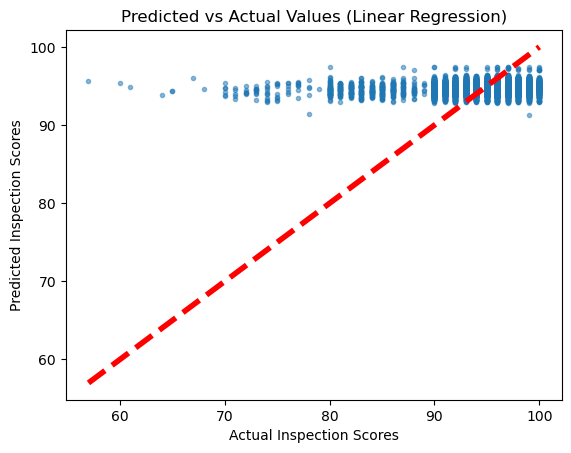

In [16]:
import matplotlib.pyplot as plt

# Plotting predicted vs. actual values
plt.scatter(y_test_score, y_pred_lin, marker=".", alpha=0.5)
plt.xlabel("Actual Inspection Scores")
plt.ylabel("Predicted Inspection Scores")
plt.title("Predicted vs Actual Values (Linear Regression)")
plt.plot(
    [y_test_score.min(), y_test_score.max()],
    [y_test_score.min(), y_test_score.max()],
    "r--",
    lw=4,
)
plt.show()

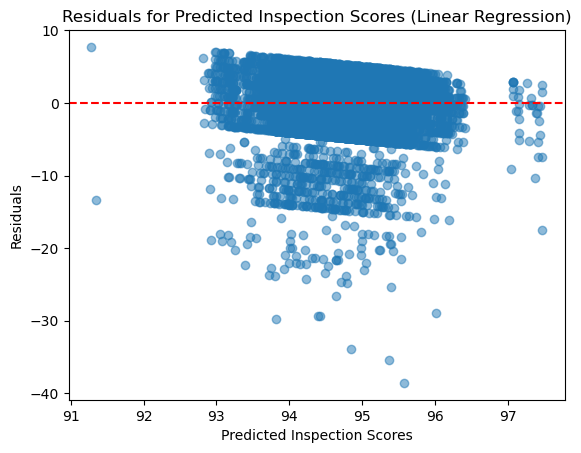

In [17]:
# Plotting residuals (difference between predicted and observed values)
residuals = y_test_score - y_pred_lin
plt.scatter(y_pred_lin, residuals, alpha=0.5)
plt.xlabel("Predicted Inspection Scores")
plt.ylabel("Residuals")
plt.title("Residuals for Predicted Inspection Scores (Linear Regression)")
plt.axhline(y=0, color="red", linestyle="--")
plt.show()

#

## Model 2: Multinomial Logistic Regression (using GRADE as our target)

In [18]:
# for the GRADE dataset (multinomial logistic regression)
from sklearn.preprocessing import (
    LabelEncoder,
    MinMaxScaler,
    StandardScaler,
    label_binarize,
)

# X = restaurant_model_grades[[i for i in list(restaurant_model_grades.columns) if i != "GRADE"]]
X = CA_restaurant_model_grades.drop("GRADE", axis=1)
y = CA_restaurant_model_grades[["GRADE"]]

# encoding target labels (A, B, C -> 0, 1, 2)
target_label = LabelEncoder()
y_encoded = target_label.fit_transform(y)
# binarize labels/one-hot encoding (needed for one-vs-rest when calculating ROC/AUC and PR curve)
y_bin = label_binarize(y_encoded, classes=[0, 1, 2])
# num_classes = len(pd.unique(y["GRADE"]))
num_classes = y_bin.shape[1]

# train/test split
X_train_grade, X_test_grade, y_train_grade, y_test_grade = train_test_split(
    X, y_bin, test_size=0.3, random_state=42
)

# normalizing our data using our MinMaxScaler
# transforms each value in the col proportionally within [0,1]
scaler = MinMaxScaler()
X_train_grade_scaled = scaler.fit_transform(X_train_grade)
X_test_grade_scaled = scaler.fit_transform(X_test_grade)
# scaler = StandardScaler()

In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier

# ABOUT THE LOGISTIC REGRESSION MODEL:
# creating multinomial logistic regression model
# testing other solvers, but apparently, 'lbfgs' is "great for multinomial"
# liblinear only handles binary classification, so we'll test for that later
# doing l2 penalty b/c only liblinear is compatible with l1 and l2

# ABOUT THE OneVsRestClassifier:
# Fits one classifier, LR in this case, per class, used in multiclass logistic regression
# will help us calculate ROC/AUC score and PR for each class relative to the others
# this is why we binarized the labels (e.g. for class A, the negative class is class B and C)
# aka we are translating multinomial log reg = multiple binary classification tasks, one per class
LR = OneVsRestClassifier(
    LogisticRegression(
        max_iter=1000, multi_class="multinomial", penalty="l2", solver="lbfgs"
    )
)

In [20]:
# predicting confidence scores
LR_y_pred = LR.fit(X_train_grade_scaled, y_train_grade).predict_proba(
    X_test_grade_scaled
)

> For multiclass classification, it seems we calculate our ROC/AUC and PR curves differently than the straightforward binary classification models we're used to seeing in class. We essentially turn our question into multiple binary classifications. For example, below, you will see the ROC curve and PR curve for each class. In the multinomial logistic regression below, the blue line (Class 0) models the ROC curve where Class 0 (or an "A" inspection score) is the positive class and Class 1 and 2 ("B" and "C" scores) are the negative class. The orange line represents the ROC curve where Class 1 (or a grade of "B") is the positive class, and Class 0 and 2 ("A" and "C" are the negative class). And so on...

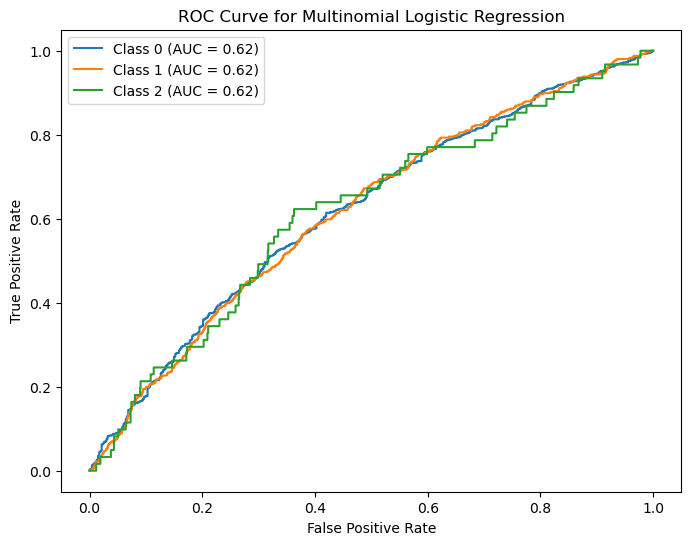

In [21]:
# the way we plotted AUC/PR curves in class is not
# supported for multiclass...doing it another way

# plotting ROC for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

# compute ROC curve and ROC area for each class
for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_grade[:, i], LR_y_pred[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(8, 6))
# plot ROC curve for a specific class
for i in range(num_classes):
    plt.plot(fpr[i], tpr[i], label=f"Class {i} (AUC = {roc_auc[i]:.2f})")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for Multinomial Logistic Regression")
plt.legend()
plt.show()

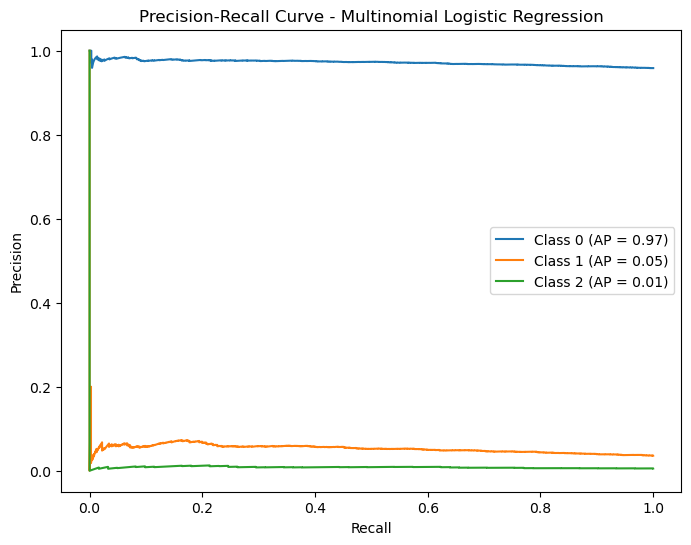

In [22]:
# plotting our PR curves for each class
precision = dict()
recall = dict()
avg_precision = dict()

# plotting each PR curve
plt.figure(figsize=(8, 6))
for i in range(num_classes):
    precision[i], recall[i], _ = precision_recall_curve(
        y_test_grade[:, i], LR_y_pred[:, i]
    )
    avg_precision[i] = average_precision_score(y_test_grade[:, i], LR_y_pred[:, i])
    plt.plot(recall[i], precision[i], label=f"Class {i} (AP = {avg_precision[i]:.2f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Multinomial Logistic Regression")
plt.legend()
plt.show()

In [23]:
# predicting class labels (another way of looking at multinomial logistic regression)
# using predict instead of predict_proba
# LR_y_pred = LR.predict(X_test_grade_scaled)

In [24]:
# from sklearn.metrics import (
#    ConfusionMatrixDisplay,
#    classification_report,
#    confusion_matrix,
# )

# plotting confusion matrix for multilabel classification
# conf = confusion_matrix(y_test_grade, LR_y_pred)

# plotting with class labels (using target_label to decode back to A, B, C)
# conf_display = ConfusionMatrixDisplay(
#    confusion_matrix=conf, display_labels=target_label.classes_
# )
# conf_display.plot(cmap="Blues")
# plt.title("Confusion Matrix for Multinomial Logistic Regression (Test)")

#

## Model 3: Random Forest Classifier (using GRADE as our target)

In [25]:
from sklearn.ensemble import RandomForestClassifier

RF_classifier = OneVsRestClassifier(
    RandomForestClassifier(n_estimators=100, random_state=42)
).fit(X_train_grade_scaled, y_train_grade)

In [26]:
RF_cls_y_pred = RF_classifier.predict_proba(X_test_grade_scaled)

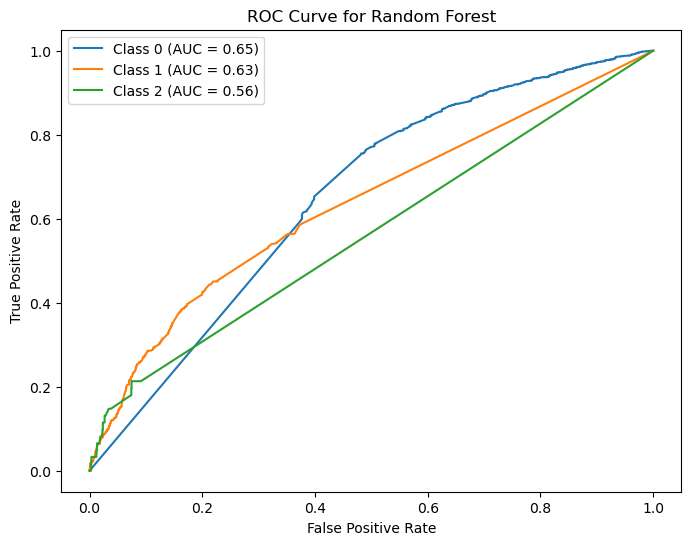

In [27]:
# Calculating ROC curve
fpr = dict()
tpr = dict()
roc_auc = dict()

# compute ROC curve and ROC area for each class
for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_grade[:, i], RF_cls_y_pred[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(8, 6))
# plot ROC curve for a specific class
for i in range(num_classes):
    plt.plot(fpr[i], tpr[i], label=f"Class {i} (AUC = {roc_auc[i]:.2f})")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for Random Forest")
plt.legend()
plt.show()

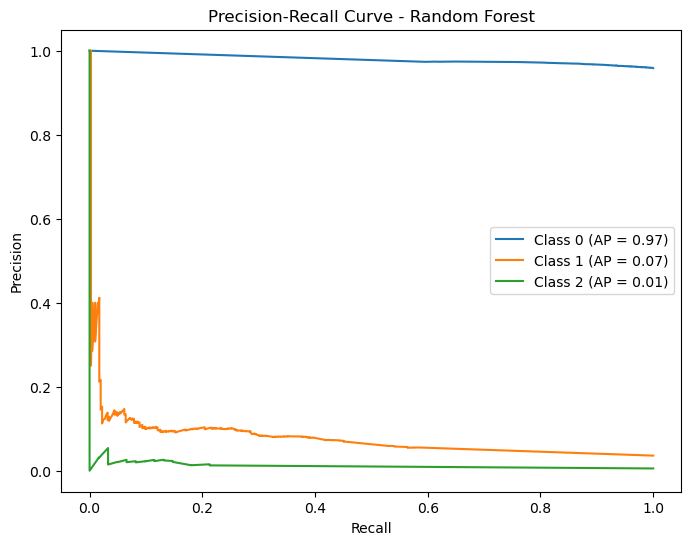

In [28]:
# plotting our PR curves for each class
precision = dict()
recall = dict()
avg_precision = dict()

# plotting each PR curve
plt.figure(figsize=(8, 6))
for i in range(num_classes):
    precision[i], recall[i], _ = precision_recall_curve(
        y_test_grade[:, i], RF_cls_y_pred[:, i]
    )
    avg_precision[i] = average_precision_score(y_test_grade[:, i], RF_cls_y_pred[:, i])
    plt.plot(recall[i], precision[i], label=f"Class {i} (AP = {avg_precision[i]:.2f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Random Forest")
plt.legend()
plt.show()

#

## Model 5: XGBoost (using GRADE as our target)

In [29]:
from xgboost import XGBClassifier

# multi:softprob > tells XGBoost to perform multi-class classification and outputs class probabilities (not just labels)
# note: we would do softmax for class labels
# eval_metric = mlogloss > common choice for multi-class classification tasks
xgb = XGBClassifier(
    objective="multi:softprob",
    num_class=3,
    eval_metric="mlogloss",
    use_label_encoder=False,
)

In [30]:
# because we used label_binarize to one hot encode our Y to calculate ROC/AUC and PR,
# we need to pass single-label form, which is what XGBoost expects

# converting one-hot encoded target to class labels
y_train_single = np.argmax(y_train_grade, axis=1)

xgb.fit(X_train_grade_scaled, y_train_single)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None, num_class=3, ...)

In [31]:
# predicting probabilities
XGB_y_pred = xgb.predict_proba(X_test_grade)

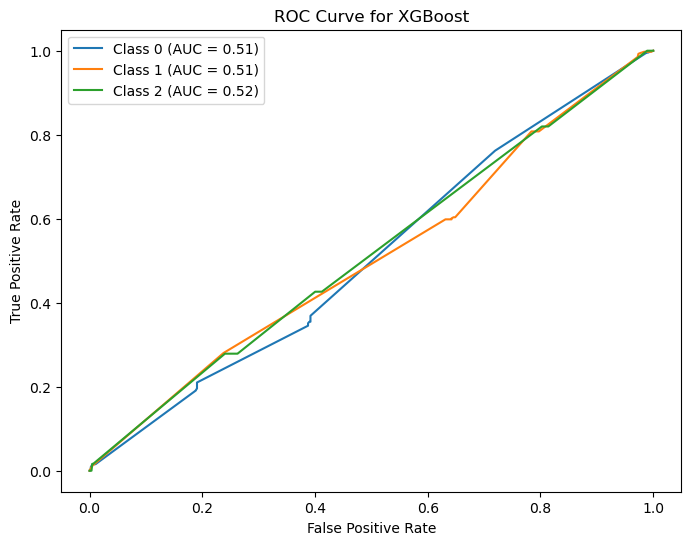

In [32]:
# Calculating ROC curve
fpr = dict()
tpr = dict()
roc_auc = dict()

# compute ROC curve and ROC area for each class
for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_grade[:, i], XGB_y_pred[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(8, 6))
# plot ROC curve for a specific class
for i in range(num_classes):
    plt.plot(fpr[i], tpr[i], label=f"Class {i} (AUC = {roc_auc[i]:.2f})")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for XGBoost")
plt.legend()
plt.show()

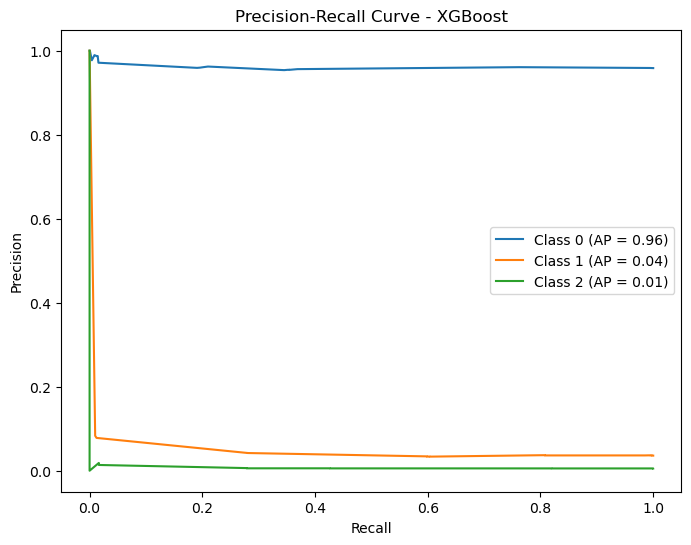

In [33]:
# plotting our PR curves for each class
precision = dict()
recall = dict()
avg_precision = dict()

# plotting each PR curve
plt.figure(figsize=(8, 6))
for i in range(num_classes):
    precision[i], recall[i], _ = precision_recall_curve(
        y_test_grade[:, i], XGB_y_pred[:, i]
    )
    avg_precision[i] = average_precision_score(y_test_grade[:, i], XGB_y_pred[:, i])
    plt.plot(recall[i], precision[i], label=f"Class {i} (AP = {avg_precision[i]:.2f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - XGBoost")
plt.legend()
plt.show()